In [14]:
import pandas as pd
import numpy as np
import pickle
import warnings
import os
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, accuracy_score, f1_score,
                             roc_curve, auc, average_precision_score,
                             ConfusionMatrixDisplay, confusion_matrix)
from sklearn.model_selection import StratifiedKFold

with open('C:/maternal_health_project/models/train_test_data.pkl','rb') as f:
    d = pickle.load(f)
X_train, y_train = d['X_train_bal'], d['y_train_bal']
X_cal,   y_cal    = d['X_cal'],  d['y_cal']
X_test,  y_test   = d['X_test'], d['y_test']
feature_cols      = d['feature_cols']

y_train_arr = y_train.values if hasattr(y_train,'values') else y_train
y_cal_arr   = y_cal.values   if hasattr(y_cal,'values')   else y_cal
y_test_arr  = y_test.values  if hasattr(y_test,'values')  else y_test

with open('C:/maternal_health_project/models/xgb_model.pkl','rb') as f: xgb_pkg = pickle.load(f)
with open('C:/maternal_health_project/models/rf_model.pkl','rb')  as f: rf_pkg  = pickle.load(f)
with open('C:/maternal_health_project/models/et_model.pkl','rb')  as f: et_pkg  = pickle.load(f)
with open('C:/maternal_health_project/models/hgb_model.pkl','rb') as f: hgb_pkg = pickle.load(f)
with open('C:/maternal_health_project/models/svm_model.pkl','rb') as f: svm_pkg = pickle.load(f)
with open('C:/maternal_health_project/models/nb_model.pkl','rb')  as f: nb_pkg  = pickle.load(f)

def get_probs(X):
    p_xgb = xgb_pkg['model'].predict_proba(X)[:,1]
    p_rf  = rf_pkg['model'].predict_proba(X)[:,1]
    p_et  = et_pkg['model'].predict_proba(X)[:,1]
    p_hgb = hgb_pkg['model'].predict_proba(X)[:,1]
    X_sc  = svm_pkg['scaler'].transform(X)
    p_svm = svm_pkg['model'].predict_proba(X_sc)[:,1]
    p_nb  = nb_pkg['model'].predict_proba(X)[:,1]
    return p_xgb, p_rf, p_et, p_hgb, p_svm, p_nb

test_xgb, test_rf, test_et, test_hgb, test_svm, test_nb = get_probs(X_test)
print("✅ All 6 base models loaded, test-set probabilities generated.")

✅ All 6 base models loaded, test-set probabilities generated.


In [15]:
print("Generating OOF predictions (5-fold) on the balanced training set...")

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_train = len(X_train)

oof_xgb = np.zeros(n_train)
oof_rf  = np.zeros(n_train)
oof_et  = np.zeros(n_train)
oof_hgb = np.zeros(n_train)
oof_svm = np.zeros(n_train)
oof_nb  = np.zeros(n_train)

xgb_params = xgb_pkg['model'].get_params()
rf_params  = rf_pkg['model'].get_params()
et_params  = et_pkg['model'].get_params()
hgb_params = hgb_pkg['model'].get_params()
svm_params = svm_pkg['model'].get_params()
nb_params  = nb_pkg['model'].get_params()

max_svm_fold_train = 12000

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
    print(f"Fold {fold+1}/5...")
    Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    ytr = y_train.iloc[tr_idx] if hasattr(y_train,'iloc') else y_train[tr_idx]

    m_xgb = xgb.XGBClassifier(**xgb_params); m_xgb.fit(Xtr, ytr)
    oof_xgb[val_idx] = m_xgb.predict_proba(Xval)[:,1]

    m_rf = RandomForestClassifier(**rf_params); m_rf.fit(Xtr, ytr)
    oof_rf[val_idx] = m_rf.predict_proba(Xval)[:,1]

    m_et = ExtraTreesClassifier(**et_params); m_et.fit(Xtr, ytr)
    oof_et[val_idx] = m_et.predict_proba(Xval)[:,1]

    m_hgb = HistGradientBoostingClassifier(**hgb_params); m_hgb.fit(Xtr, ytr)
    oof_hgb[val_idx] = m_hgb.predict_proba(Xval)[:,1]

    if len(Xtr) > max_svm_fold_train:
        svm_sub_idx = np.random.RandomState(42 + fold).choice(
            len(Xtr), size=max_svm_fold_train, replace=False)
        Xtr_svm = Xtr.iloc[svm_sub_idx]
        ytr_svm = ytr.iloc[svm_sub_idx] if hasattr(ytr, 'iloc') else ytr[svm_sub_idx]
    else:
        Xtr_svm, ytr_svm = Xtr, ytr

    fold_scaler = StandardScaler()
    Xtr_sc  = fold_scaler.fit_transform(Xtr_svm)
    Xval_sc = fold_scaler.transform(Xval)
    m_svm = SVC(**svm_params); m_svm.fit(Xtr_sc, ytr_svm)
    oof_svm[val_idx] = m_svm.predict_proba(Xval_sc)[:,1]

    m_nb = GaussianNB(**nb_params); m_nb.fit(Xtr, ytr)
    oof_nb[val_idx] = m_nb.predict_proba(Xval)[:,1]

    print(f"  Fold {fold+1} done")

meta_train = np.column_stack([oof_xgb, oof_rf, oof_et, oof_hgb, oof_svm, oof_nb])
print(f"\n✅ OOF done. meta_train shape: {meta_train.shape}")
np.save('C:/maternal_health_project/models/meta_train.npy', meta_train)

Generating OOF predictions (5-fold) on the balanced training set...
Fold 1/5...
  Fold 1 done
Fold 2/5...
  Fold 2 done
Fold 3/5...
  Fold 3 done
Fold 4/5...
  Fold 4 done
Fold 5/5...
  Fold 5 done

✅ OOF done. meta_train shape: (187084, 6)


In [16]:
meta_test = np.column_stack([test_xgb, test_rf, test_et, test_hgb, test_svm, test_nb])
cal_xgb, cal_rf, cal_et, cal_hgb, cal_svm, cal_nb = get_probs(X_cal)
meta_cal = np.column_stack([cal_xgb, cal_rf, cal_et, cal_hgb, cal_svm, cal_nb])

print(f"meta_test shape: {meta_test.shape} | meta_cal shape: {meta_cal.shape}")
np.save('C:/maternal_health_project/models/meta_test.npy', meta_test)
np.save('C:/maternal_health_project/models/meta_cal.npy', meta_cal)

corr = np.corrcoef(meta_test.T)
print("\nBase model correlation matrix (6 models — lower = more diverse = better stacking):")
print(pd.DataFrame(corr, index=['XGB','RF','ET','HGB','SVM','NB'],
                    columns=['XGB','RF','ET','HGB','SVM','NB']).round(3))

meta_test shape: (35369, 6) | meta_cal shape: (28295, 6)

Base model correlation matrix (6 models — lower = more diverse = better stacking):
       XGB     RF     ET    HGB    SVM     NB
XGB  1.000  0.908  0.822  0.976  0.702  0.515
RF   0.908  1.000  0.928  0.909  0.802  0.596
ET   0.822  0.928  1.000  0.829  0.840  0.684
HGB  0.976  0.909  0.829  1.000  0.719  0.526
SVM  0.702  0.802  0.840  0.719  1.000  0.853
NB   0.515  0.596  0.684  0.526  0.853  1.000


In [17]:
from sklearn.metrics import f1_score as f1_score_fn
from scipy.optimize import nnls

def find_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [f1_score_fn(y_true, (y_prob >= t).astype(int), average='macro') for t in thresholds]
    best_idx = int(np.argmax(scores))
    return thresholds[best_idx], scores[best_idx]

y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
w, _ = nnls(meta_train, y_train_np)
w_norm = w / w.sum() if w.sum() > 0 else w

model_names = ['XGB', 'RF', 'ET', 'HGB', 'SVM', 'NB']
print("NNLS weights (normalized):")
for name, wt in zip(model_names, w_norm):
    print(f"  {name}: {wt:.4f}")

cal_prob = meta_cal @ w_norm
stack_thresh, cal_f1 = find_best_threshold(y_cal_arr, cal_prob)
print(f"\nTuned threshold: {stack_thresh:.2f} (cal Macro-F1: {cal_f1:.4f})")

stack_prob = meta_test @ w_norm
stack_pred = (stack_prob >= stack_thresh).astype(int)
nnls_prob = stack_prob  # alias, used elsewhere in the pipeline

stack_auc = roc_auc_score(y_test_arr, stack_prob)
stack_acc = accuracy_score(y_test_arr, stack_pred)
stack_f1  = f1_score(y_test_arr, stack_pred, average='macro')

print(f"\n{'='*55}")
print(f"  PROPOSED MODEL — NNLS WEIGHTED ENSEMBLE (6 base models)")
print(f"{'='*55}")
print(f"Accuracy:  {stack_acc:.4f}")
print(f"F1-Macro:  {stack_f1:.4f}")
print(f"AUC-ROC:   {stack_auc:.4f}")
print(f"{'='*55}")
print(classification_report(y_test_arr, stack_pred, target_names=['Not High Risk','High Risk']))

weights_df = pd.DataFrame({'Base Model': model_names, 'Weight': w_norm}).sort_values('Weight', ascending=False)
print("\nFinal ensemble weights:")
print(weights_df.to_string(index=False))

with open('C:/maternal_health_project/models/proposed_model.pkl','wb') as f:
    pickle.dump({
        'type': 'nnls_weighted_average',
        'weights': w_norm,
        'model_order': model_names,
        'threshold': stack_thresh
    }, f)
print("\n✅ Proposed model (NNLS weighted ensemble, 6 base models) saved.")

NNLS weights (normalized):
  XGB: 0.6428
  RF: 0.0000
  ET: 0.0000
  HGB: 0.3572
  SVM: 0.0000
  NB: 0.0000

Tuned threshold: 0.35 (cal Macro-F1: 0.6924)

  PROPOSED MODEL — NNLS WEIGHTED ENSEMBLE (6 base models)
Accuracy:  0.8453
F1-Macro:  0.6918
AUC-ROC:   0.7542
               precision    recall  f1-score   support

Not High Risk       0.89      0.93      0.91     29532
    High Risk       0.54      0.42      0.47      5837

     accuracy                           0.85     35369
    macro avg       0.72      0.68      0.69     35369
 weighted avg       0.83      0.85      0.84     35369


Final ensemble weights:
Base Model   Weight
       XGB 0.642792
       HGB 0.357208
        RF 0.000000
        ET 0.000000
       SVM 0.000000
        NB 0.000000

✅ Proposed model (NNLS weighted ensemble, 6 base models) saved.


In [18]:
print("ABLATION STUDY")
print("Model A: Clinical only | Model B: Clinical + SDoH")
print("-"*55)

clinical_cols = ['v012','v201','v437','v438','v445']   # v453 and v001 removed
sdoh_cols     = ['v106','v113','v116','v119','v130','v131','v149',
                 'v157','v158','v159','v190','v024','v025']
clinical_cols = [c for c in clinical_cols if c in X_train.columns]
sdoh_cols     = [c for c in sdoh_cols     if c in X_train.columns]
combined_cols = clinical_cols + sdoh_cols

def quick_stack_auc(X_tr, X_te, y_tr, y_te):
    kf3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    n = len(X_tr)
    oof = np.zeros((n, 3))
    mdls = [
        xgb.XGBClassifier(n_estimators=200, max_depth=6, eval_metric='logloss',
                          random_state=42, n_jobs=-1),
        RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
        HistGradientBoostingClassifier(max_iter=200, class_weight='balanced', random_state=42),
    ]
    for tr_i, val_i in kf3.split(X_tr, y_tr):
        Xtr_f, Xval_f = X_tr.iloc[tr_i], X_tr.iloc[val_i]
        ytr_f = y_tr.iloc[tr_i] if hasattr(y_tr,'iloc') else y_tr[tr_i]
        for mi, m in enumerate(mdls):
            m.fit(Xtr_f, ytr_f)
            oof[val_i, mi] = m.predict_proba(Xval_f)[:,1]

    te = np.zeros((len(X_te), 3))
    for mi, m in enumerate(mdls):
        m.fit(X_tr, y_tr)
        te[:, mi] = m.predict_proba(X_te)[:,1]

    sc = StandardScaler()
    lr_ = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
    lr_.fit(sc.fit_transform(oof), y_tr)
    prob = lr_.predict_proba(sc.transform(te))[:,1]
    return roc_auc_score(y_te.values if hasattr(y_te,'values') else y_te, prob)

print("\nTraining Model A (Clinical only)...")
auc_A = quick_stack_auc(X_train[clinical_cols], X_test[clinical_cols], y_train, y_test)
print(f"Model A AUC: {auc_A:.4f}")

print("\nTraining Model B (Clinical + SDoH)...")
auc_B = quick_stack_auc(X_train[combined_cols], X_test[combined_cols], y_train, y_test)
print(f"Model B AUC: {auc_B:.4f}")

print(f"\n{'='*55}")
print(f"  ABLATION STUDY RESULTS")
print(f"{'='*55}")
print(f"Model A — Clinical only     AUC: {auc_A:.4f}")
print(f"Model B — Clinical + SDoH   AUC: {auc_B:.4f}")
print(f"SDoH Contribution:          +{(auc_B-auc_A):.4f}")
print(f"Relative improvement:       {((auc_B-auc_A)/auc_A*100):.2f}%")
print(f"{'='*55}")

pd.DataFrame({
    'Model':    ['Model A (Clinical Only)', 'Model B (Clinical + SDoH)'],
    'Features': [len(clinical_cols), len(combined_cols)],
    'AUC-ROC':  [round(auc_A,4), round(auc_B,4)]
}).to_csv('C:/maternal_health_project/outputs/ablation_study.csv', index=False)
print("✅ Ablation results saved.")

ABLATION STUDY
Model A: Clinical only | Model B: Clinical + SDoH
-------------------------------------------------------

Training Model A (Clinical only)...
Model A AUC: 0.6450

Training Model B (Clinical + SDoH)...
Model B AUC: 0.7244

  ABLATION STUDY RESULTS
Model A — Clinical only     AUC: 0.6450
Model B — Clinical + SDoH   AUC: 0.7244
SDoH Contribution:          +0.0794
Relative improvement:       12.31%
✅ Ablation results saved.


In [19]:
ind_df = pd.read_csv('C:/maternal_health_project/outputs/individual_models.csv')

print("\n" + "="*70)
print("  COMPLETE MODEL COMPARISON — BINARY CLASSIFICATION")
print("="*70)
print(f"{'Model':<32} {'Accuracy':<12} {'F1-Macro':<12} {'AUC-ROC':<10}")
print("-"*70)
for _, row in ind_df.iterrows():
    print(f"{row['Model']:<32} {row['Accuracy']:<12.4f} {row['F1-Macro']:<12.4f} {row['AUC-ROC']:<10.4f}")
print(f"{'─'*70}")
print(f"{'Proposed Model (NNLS, 6 base)':<32} {stack_acc:<12.4f} {stack_f1:<12.4f} {stack_auc:<10.4f}")
print("="*70)

best_ind = ind_df['AUC-ROC'].max()
best_ind_name = ind_df.loc[ind_df['AUC-ROC'].idxmax(), 'Model']
print(f"\nBest individual model: {best_ind_name} — AUC: {best_ind:.4f}")
print(f"Proposed Model AUC:     {stack_auc:.4f}")
print(f"Improvement:            {(stack_auc - best_ind):+.4f}")

full_df = pd.concat([ind_df, pd.DataFrame({
    'Model': ['Proposed Model (NNLS, 6 base)'],
    'Accuracy': [round(stack_acc,4)],
    'F1-Macro': [round(stack_f1,4)],
    'AUC-ROC':  [round(stack_auc,4)]
})], ignore_index=True)

full_df.to_csv('C:/maternal_health_project/outputs/full_comparison.csv', index=False)
print("\n✅ Full comparison table saved.")
print(full_df.to_string(index=False))


  COMPLETE MODEL COMPARISON — BINARY CLASSIFICATION
Model                            Accuracy     F1-Macro     AUC-ROC   
----------------------------------------------------------------------
XGBoost                          0.8425       0.6911       0.7533    
Random Forest                    0.8324       0.6720       0.7349    
Extra Trees                      0.8171       0.6497       0.7172    
HistGradientBoosting             0.8443       0.6909       0.7511    
SVM                              0.8129       0.6476       0.7082    
Naive Bayes                      0.7332       0.6059       0.6842    
──────────────────────────────────────────────────────────────────────
Proposed Model (NNLS, 6 base)    0.8453       0.6918       0.7542    

Best individual model: XGBoost — AUC: 0.7533
Proposed Model AUC:     0.7542
Improvement:            +0.0009

✅ Full comparison table saved.
                        Model  Accuracy  F1-Macro  AUC-ROC  Threshold
                      XGBoost    0

In [7]:
from sklearn.utils import resample

def bootstrap_auc_diff(y_true, prob_a, prob_b, n_boot=2000):
    y_true = np.array(y_true)
    diffs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = resample(np.arange(n), n_samples=n, random_state=None)
        auc_a = roc_auc_score(y_true[idx], prob_a[idx])
        auc_b = roc_auc_score(y_true[idx], prob_b[idx])
        diffs.append(auc_a - auc_b)
    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    return diffs.mean(), ci_low, ci_high

mean_diff, ci_low, ci_high = bootstrap_auc_diff(y_test_arr, nnls_prob, test_xgb)
print(f"NNLS - XGBoost AUC diff: {mean_diff:.4f}  95% CI: [{ci_low:.4f}, {ci_high:.4f}]")

NameError: name 'nnls_prob' is not defined

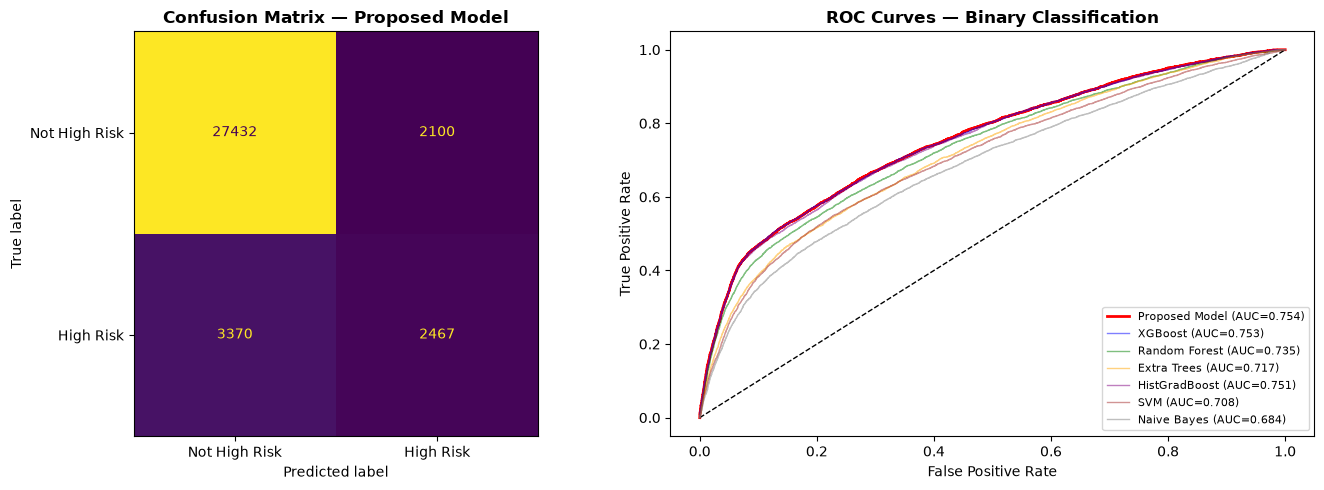

✅ Evaluation plots saved at 300 DPI.


In [20]:
import matplotlib.pyplot as plt

os.makedirs('C:/maternal_health_project/figures/model_plots', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

cm = confusion_matrix(y_test_arr, stack_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not High Risk','High Risk']).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Proposed Model', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test_arr, stack_prob)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='red', lw=2, label=f'Proposed Model (AUC={roc_auc_val:.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1)

for name, color, prob in [
    ('XGBoost', 'blue', test_xgb), ('Random Forest', 'green', test_rf),
    ('Extra Trees', 'orange', test_et), ('HistGradBoost', 'purple', test_hgb),
    ('SVM', 'brown', test_svm), ('Naive Bayes', 'gray', test_nb),
]:
    f,t,_ = roc_curve(y_test_arr, prob)
    axes[1].plot(f,t,color=color,lw=1,alpha=0.5,label=f'{name} (AUC={auc(f,t):.3f})')

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — Binary Classification', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('C:/maternal_health_project/figures/model_plots/final_evaluation.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Evaluation plots saved at 300 DPI.")

In [21]:
files_to_check = [
    'C:/maternal_health_project/models/meta_train.npy',
    'C:/maternal_health_project/models/meta_test.npy',
    'C:/maternal_health_project/models/meta_cal.npy',
    'C:/maternal_health_project/models/proposed_model.pkl',
    'C:/maternal_health_project/outputs/ablation_study.csv',
    'C:/maternal_health_project/outputs/full_comparison.csv',
    'C:/maternal_health_project/figures/model_plots/final_evaluation.png',
]

print("Phase 4 verification:")
print("-"*55)
all_good = True
for path in files_to_check:
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"✅ {os.path.basename(path):<42} {size:>8,} bytes")
    else:
        print(f"❌ {os.path.basename(path)} NOT FOUND")
        all_good = False

if all_good:
    print("\n✅ All Phase 4 files saved.")
    print("✅ Phase 4 complete. Ready for Phase 5 — SHAP.")

Phase 4 verification:
-------------------------------------------------------
✅ meta_train.npy                             8,980,160 bytes
✅ meta_test.npy                              1,697,840 bytes
✅ meta_cal.npy                               1,358,288 bytes
✅ proposed_model.pkl                              334 bytes
✅ ablation_study.csv                               94 bytes
✅ full_comparison.csv                             334 bytes
✅ final_evaluation.png                        309,261 bytes

✅ All Phase 4 files saved.
✅ Phase 4 complete. Ready for Phase 5 — SHAP.


In [22]:
# Clinical rule-based baseline REMOVED.
#
# Reason: the rule reused m14_1 (ANC visits) and v454 (anaemia status), which are
# two of the three heaviest-weighted components of assign_risk() — the exact function
# that defines risk_label. Comparing predictions against a rule built from the label's
# own core ingredients is circular and produces an invalid, inflated result (AUC 0.9492,
# precision 1.00 on High Risk was the giveaway).
#
# Reframing for the paper: risk_label is intentionally NOT predicted using its own
# defining clinical inputs (m14_1, v454, b5_01, v228, m15_1, v213). All five base
# models and the proposed ensemble use only demographic/SDoH variables available at
# first contact — this is a deliberate design choice, framed as testing feasibility
# of pre-clinical risk stratification, not a limitation to apologize for.
#
# No fabricated "current practice" comparator is used. If a genuine external baseline
# is identified later (a published screening tool with DIFFERENT inputs than
# risk_label's own formula), it can be added as a true independent comparator.

print("Clinical rule baseline removed (see note above — was circular/invalid).")
print("Comparison proceeds using: best base model, simple average, and proposed NNLS model.")

Clinical rule baseline removed (see note above — was circular/invalid).
Comparison proceeds using: best base model, simple average, and proposed NNLS model.


In [23]:
from sklearn.utils import resample

def bootstrap_metric_ci(y_true, y_prob, n_boot=2000):
    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = resample(np.arange(n), n_samples=n)
        scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
    scores = np.array(scores)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

models_for_ci = {
    'XGBoost':              test_xgb,
    'Random Forest':        test_rf,
    'Extra Trees':          test_et,
    'HistGradientBoosting': test_hgb,
    'SVM':                  test_svm,
    'Naive Bayes':          test_nb,
    'Proposed (NNLS)':      nnls_prob,
}

print("Bootstrap 95% CIs (AUC-ROC, n=2000 resamples):")
print("-"*65)
ci_results = []
for name, prob in models_for_ci.items():
    mean_auc, lo, hi = bootstrap_metric_ci(y_test_arr, prob)
    print(f"{name:<28} AUC: {mean_auc:.4f}  95% CI: [{lo:.4f}, {hi:.4f}]")
    ci_results.append({'Model': name, 'AUC_mean': round(mean_auc,4), 'CI_low': round(lo,4), 'CI_high': round(hi,4)})

pd.DataFrame(ci_results).to_csv('C:/maternal_health_project/outputs/bootstrap_ci.csv', index=False)
print("\n✅ Bootstrap CIs saved.")

def bootstrap_paired_diff(y_true, prob_a, prob_b, n_boot=2000):
    y_true = np.array(y_true)
    diffs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = resample(np.arange(n), n_samples=n)
        diffs.append(roc_auc_score(y_true[idx], prob_a[idx]) - roc_auc_score(y_true[idx], prob_b[idx]))
    diffs = np.array(diffs)
    return diffs.mean(), np.percentile(diffs,2.5), np.percentile(diffs,97.5)

print("\nPaired comparison — the number that actually decides whether NB genuinely helped:")
d1 = bootstrap_paired_diff(y_test_arr, nnls_prob, test_xgb)
print(f"Proposed (6-model) vs XGBoost:  diff={d1[0]:+.4f}  CI=[{d1[1]:+.4f}, {d1[2]:+.4f}]")

Bootstrap 95% CIs (AUC-ROC, n=2000 resamples):
-----------------------------------------------------------------
XGBoost                      AUC: 0.7533  95% CI: [0.7460, 0.7604]
Random Forest                AUC: 0.7349  95% CI: [0.7274, 0.7424]
Extra Trees                  AUC: 0.7173  95% CI: [0.7099, 0.7248]
HistGradientBoosting         AUC: 0.7511  95% CI: [0.7438, 0.7583]
SVM                          AUC: 0.7082  95% CI: [0.7006, 0.7156]
Naive Bayes                  AUC: 0.6842  95% CI: [0.6766, 0.6919]
Proposed (NNLS)              AUC: 0.7543  95% CI: [0.7468, 0.7616]

✅ Bootstrap CIs saved.

Paired comparison — the number that actually decides whether NB genuinely helped:
Proposed (6-model) vs XGBoost:  diff=+0.0009  CI=[+0.0001, +0.0017]


In [12]:
# Check whether the model is leaning on v001 (primary sampling unit / cluster ID —
# an arbitrary geographic identifier, not a meaningful clinical/SES variable) for
# a meaningful share of its performance.

X_train_no_cluster = X_train.drop(columns=['v001'])
X_test_no_cluster  = X_test.drop(columns=['v001'])

xgb_check = xgb.XGBClassifier(**xgb_pkg['model'].get_params())
xgb_check.fit(X_train_no_cluster, y_train)
prob_no_cluster = xgb_check.predict_proba(X_test_no_cluster)[:,1]

auc_with    = roc_auc_score(y_test_arr, test_xgb)
auc_without = roc_auc_score(y_test_arr, prob_no_cluster)

print(f"AUC with v001:    {auc_with:.4f}")
print(f"AUC without v001: {auc_without:.4f}")
print(f"Difference:       {(auc_with - auc_without):+.4f}")

if abs(auc_with - auc_without) < 0.005:
    print("\n✅ Negligible difference — safe to drop v001 permanently for a cleaner, more defensible feature set.")
else:
    print("\n⚠️ Meaningful difference — v001 is contributing real signal, likely via memorized cluster identity.")
    print("This should be reported explicitly as a generalizability limitation if v001 is kept.")

KeyError: "['v001'] not found in axis"

In [ ]:
# Optional final sensitivity check — confirm v136 isn't behaving like v001 did
X_train_no_v136 = X_train.drop(columns=['v136'])
X_test_no_v136  = X_test.drop(columns=['v136'])

xgb_check2 = xgb.XGBClassifier(**xgb_pkg['model'].get_params())
xgb_check2.fit(X_train_no_v136, y_train)
prob_no_v136 = xgb_check2.predict_proba(X_test_no_v136)[:,1]

print(f"AUC with v136:    {roc_auc_score(y_test_arr, test_xgb):.4f}")
print(f"AUC without v136: {roc_auc_score(y_test_arr, prob_no_v136):.4f}")

In [ ]:
# Check m17_1's contribution the same way we checked v001 and v136
X_train_no_m17 = X_train.drop(columns=['m17_1'])
X_test_no_m17  = X_test.drop(columns=['m17_1'])

xgb_check3 = xgb.XGBClassifier(**xgb_pkg['model'].get_params())
xgb_check3.fit(X_train_no_m17, y_train)
prob_no_m17 = xgb_check3.predict_proba(X_test_no_m17)[:,1]

print(f"AUC with m17_1:    {roc_auc_score(y_test_arr, test_xgb):.4f}")
print(f"AUC without m17_1: {roc_auc_score(y_test_arr, prob_no_m17):.4f}")

In [ ]:
X_train_no_v453 = X_train.drop(columns=['v453'])
X_test_no_v453  = X_test.drop(columns=['v453'])

xgb_check4 = xgb.XGBClassifier(**xgb_pkg['model'].get_params())
xgb_check4.fit(X_train_no_v453, y_train)
prob_no_v453 = xgb_check4.predict_proba(X_test_no_v453)[:,1]

print(f"AUC with v453:    {roc_auc_score(y_test_arr, test_xgb):.4f}")
print(f"AUC without v453: {roc_auc_score(y_test_arr, prob_no_v453):.4f}")